In [34]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/dataset_split"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection\dataset_split


In [35]:
train_images = root / "images" / "train"
train_labels = root / "labels" / "train"

test_images = root / "images" / "test"
test_labels = root / "labels" / "test"

print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection\dataset_split\images\train
Train labels path: Sign Language Detection\dataset_split\labels\train


In [36]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

def load_detection_data(img_dir, label_dir, img_size=(224, 224)):
    images = []
    boxes = [] # Tutaj trafią tylko współrzędne [x, y, w, h]

    file_names = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

    for file_name in file_names:
        # 1. Wczytaj obraz
        img_path = os.path.join(img_dir, file_name.replace('.txt', '.jpg'))
        img = cv2.imread(img_path)
        if img is None: continue
        
        h_img, w_img, _ = img.shape
        
        # 2. Wczytaj etykietę (zakładamy format: class x_center y_center w h)
        with open(os.path.join(label_dir, file_name), 'r') as f:
            line = f.readline().split()
            if not line: continue
            
            # Pomijamy klasę (line[0]), bo ten model szuka tylko dłoni ogólnie
            # Dane w pliku są zazwyczaj znormalizowane. Jeśli nie są - podziel przez w_img/h_img
            cx, cy, w, h = map(float, line[1:]) 
            
            # Przeliczamy z center (środek) na top-left (lewy górny róg) - łatwiej się to wycina
            x = cx - (w / 2)
            y = cy - (h / 2)
            
            boxes.append([x, y, w, h])

        # 3. Resize obrazu do formatu wejściowego sieci
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        images.append(img / 255.0)

    return np.array(images), np.array(boxes)

# Wczytanie danych
X_train, Y_train = load_detection_data(train_images, train_labels)

X_val, Y_val = load_detection_data(test_images, test_labels)



# Podział na trening i walidację
# X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_locator_model():
    # 1. Backbone (kręgosłup sieci) - MobileNetV2 bez ostatnich warstw
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False # Zamrażamy na początek

    # 2. Head (głowa sieci) - nasza własna część regresyjna
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x) # Zapobiega overfittingowi
    x = layers.Dense(64, activation='relu')(x)
    
    # Wyjście: 4 wartości [x, y, w, h]
    # Sigmoid wymusza wynik w zakresie 0-1
    outputs = layers.Dense(4, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

detector = build_locator_model()

In [38]:
# Kompilacja
detector.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',      # Minimalizujemy błąd odległości
    metrics=['mae', 'accuracy']  # Średni błąd bezwzględny (dla czytelności)
)

# Callbacks - przydatne narzędzia
callbacks = [
    # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'hand_detector_best.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
    # Zmniejsz learning rate, gdy sieć przestanie się uczyć
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3
    )
]

# Start treningu
history = detector.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,       # Regresja wymaga zazwyczaj więcej epok niż klasyfikacja
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 550ms/step - accuracy: 0.2874 - loss: 0.0827 - mae: 0.2223 - val_accuracy: 0.6154 - val_loss: 0.0214 - val_mae: 0.1134 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.4713 - loss: 0.0235 - mae: 0.1203 - val_accuracy: 0.6154 - val_loss: 0.0227 - val_mae: 0.1201 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.6322 - loss: 0.0269 - mae: 0.1275 - val_accuracy: 0.6154 - val_loss: 0.0206 - val_mae: 0.1171 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.6322 - loss: 0.0248 - mae: 0.1241 - val_accuracy: 0.5385 - val_loss: 0.0173 - val_mae: 0.1044 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.5747 - loss: 0.0218 - mae: 0.1155 - val_accuracy: 0.5385 - val_loss: 0.0126 - val_mae: 0.0840 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.5862 - loss: 0.0174 - mae:

In [41]:
score = detector.evaluate(X_val, Y_val)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8462 - loss: 0.0065 - mae: 0.0639
Test loss: 0.006451294291764498
Test accuracy: 0.06394696980714798


In [39]:
def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 20
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


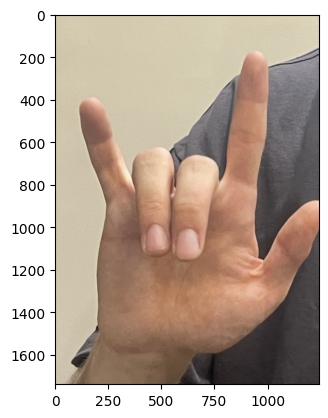

In [40]:
# Test

import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")

cropped_img, coords = crop_hand("./Sign Language Detection/dataset_split/images/test/IMG_7372.JPG", detector)

if cropped_img.size > 0:
    cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)